In [1]:
# 1. Imports des librairies standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration esthétique
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None) # Pour voir toutes les colonnes

# 2. Chargement des données
df = pd.read_csv('../data/raw/telco_churn.csv')

# 3. Affichage de l'en-tête
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Afficher les informations techniques des colonnes
print("--- INFO DU DATASET ---")
df.info()

print("\n--- VALEURS MANQUANTES ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

--- INFO DU DATASET ---
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nu

In [3]:
# 1. Forcer la conversion en numérique ('coerce' transforme les erreurs en vrai NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. On vérifie combien de valeurs manquantes sont apparues
print("Valeurs manquantes démasquées :", df['TotalCharges'].isnull().sum())

# 3. Comme il n'y en a que 11 sur 7000 (négligeable), on les supprime de la base
df = df.dropna()

# 4. On vérifie que c'est bien corrigé (TotalCharges doit être float64)
df.info()

Valeurs manquantes démasquées : 11
<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 

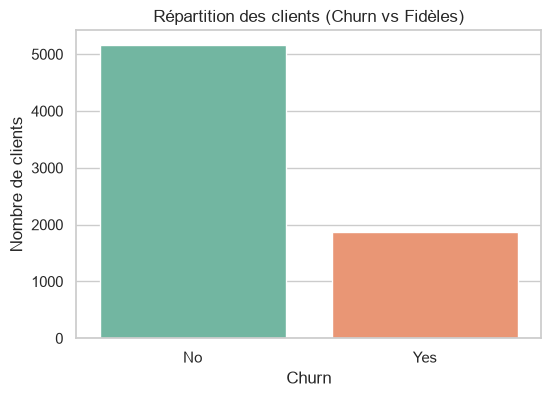

--- Pourcentage de répartition ---
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


In [4]:
# Affichage graphique du déséquilibre
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2')
plt.title('Répartition des clients (Churn vs Fidèles)')
plt.ylabel('Nombre de clients')
plt.show()

# Affichage des pourcentages exacts
print("--- Pourcentage de répartition ---")
print(round(df['Churn'].value_counts(normalize=True) * 100, 2))

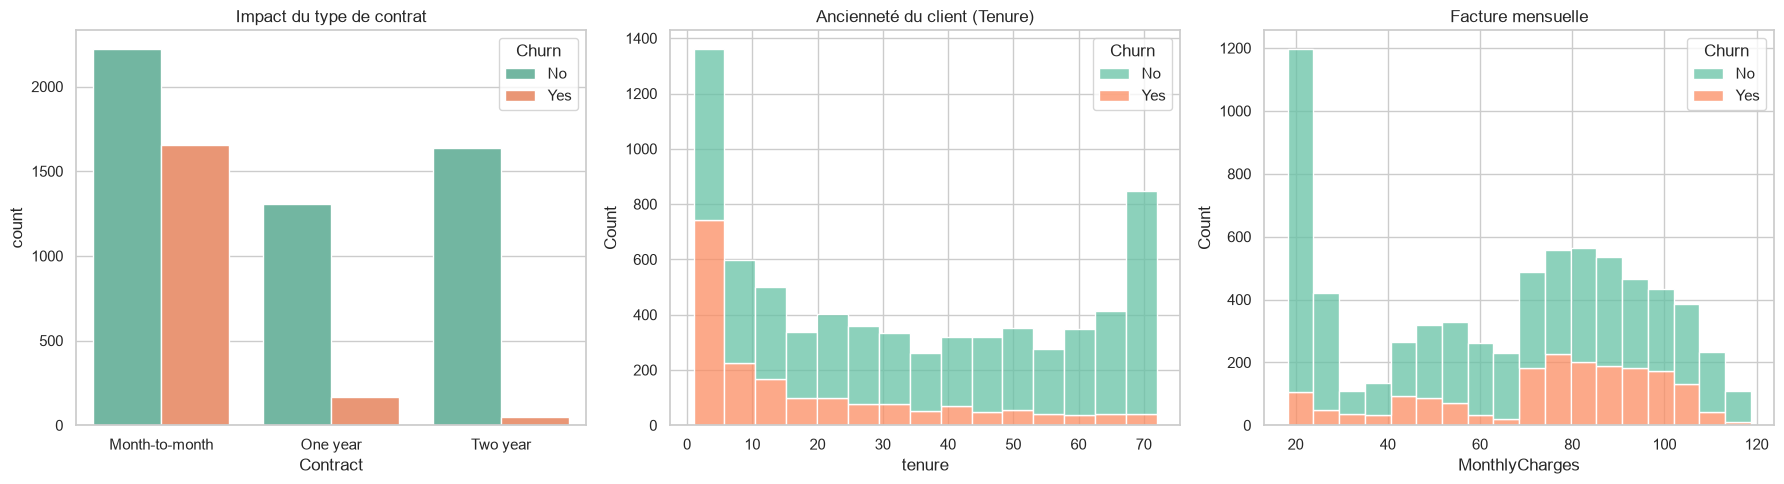

In [5]:
# --- ANALYSE DES CAUSES DE DÉSABONNEMENT ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graphique 1 : Le type de contrat
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2', ax=axes[0])
axes[0].set_title('Impact du type de contrat')

# Graphique 2 : L'ancienneté du client (en mois)
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette='Set2', ax=axes[1])
axes[1].set_title("Ancienneté du client (Tenure)")

# Graphique 3 : La facture mensuelle
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', palette='Set2', ax=axes[2])
axes[2].set_title('Facture mensuelle')

plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

# 1. Suppression de la colonne ID (Elle ne sert à rien pour deviner si quelqu'un part)
df = df.drop('customerID', axis=1)

# 2. Transformer notre cible (Churn) en binaire (1 = Part, 0 = Reste)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. Transformer tout le reste du texte en colonnes mathématiques (One-Hot Encoding)
# Ex: La colonne "InternetService" devient "InternetService_Fiber_optic" (0 ou 1)
df_encoded = pd.get_dummies(df, drop_first=True)

# 4. Séparer la cible (Y) de nos indices (X)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# 5. Couper les données : 80% pour l'entraînement, 20% pour l'examen final de l'IA
# L'option 'stratify=y' garantit qu'on garde les mêmes 26% de churn dans les deux tas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Données prêtes pour le Machine Learning !")
print(f"Taille du jeu d'entraînement : {X_train.shape[0]} clients")
print(f"Taille du jeu d'examen : {X_test.shape[0]} clients")
print(f"Nombre de variables mathématiques (colonnes) : {X_train.shape[1]}")

✅ Données prêtes pour le Machine Learning !
Taille du jeu d'entraînement : 5625 clients
Taille du jeu d'examen : 1407 clients
Nombre de variables mathématiques (colonnes) : 30


In [7]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Création et entraînement du modèle XGBoost
model = XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

# 2. Prédiction sur le jeu d'examen (Test)
y_pred = model.predict(X_test)

# 3. Affichage des résultats d'évaluation
print("--- MATRICE DE CONFUSION ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- RAPPORT DE CLASSIFICATION ---")
print(classification_report(y_test, y_pred))

--- MATRICE DE CONFUSION ---
[[888 145]
 [177 197]]

--- RAPPORT DE CLASSIFICATION ---
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1033
           1       0.58      0.53      0.55       374

    accuracy                           0.77      1407
   macro avg       0.70      0.69      0.70      1407
weighted avg       0.77      0.77      0.77      1407



/var/folders/zl/mz9q82vx3js0yncwgbt6tlrm0000gn/T/ipykernel_3568/110157788.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance, x='Importance', y='Variable', palette='viridis')


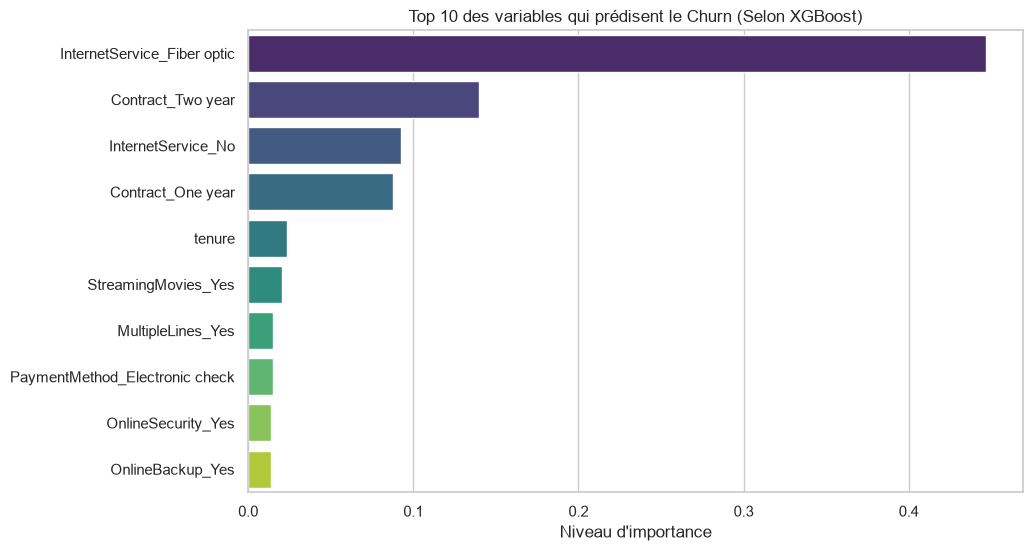

In [8]:
# Récupération de l'importance des variables
importances = model.feature_importances_
features = X_train.columns

# Création d'un DataFrame pour trier joliment
df_importance = pd.DataFrame({'Variable': features, 'Importance': importances})
df_importance = df_importance.sort_values(by='Importance', ascending=False).head(10)

# Affichage graphique
plt.figure(figsize=(10, 6))
sns.barplot(data=df_importance, x='Importance', y='Variable', palette='viridis')
plt.title('Top 10 des variables qui prédisent le Churn (Selon XGBoost)')
plt.xlabel('Niveau d\'importance')
plt.ylabel('')
plt.show()